# Data Loader Latency Visualization

Visualizes GPU data loader benchmark results as faceted heatmaps.

For each output variable (`min_step_ms`, `mean_step_ms`), a figure is produced with three panels (one per `chunk` value). Within each panel: `dec` on the x-axis, `ring` on the y-axis, color = output value. Color scale is shared across the three panels of a figure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the benchmark summary CSV (relative to the notebook's working directory)
CSV_PATH = 'slurm_logs/bench_loader_latency_624564_summary.csv'

In [2]:
# Header line starts with '# ' so skip it and supply explicit column names.
df = pd.read_csv(
    CSV_PATH,
    skiprows=1,
    names=['chunk', 'ring', 'dec', 'min_step_ms', 'mean_step_ms', 'trainer_waits'],
)
print('shape:', df.shape)
df.head()

shape: (27, 6)


,chunk,ring,dec,min_step_ms,mean_step_ms,trainer_waits
0,32,2,8,3.89,0.63,500
1,32,2,16,3.86,0.63,500
2,32,2,32,3.83,0.62,500
3,32,4,8,3.91,0.63,500
4,32,4,16,3.88,0.63,500


In [3]:
df.describe()

,chunk,ring,dec,min_step_ms,mean_step_ms,trainer_waits
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.0
mean,74.666667,4.666667,18.666667,5.064074,0.660370,500.0
std,40.671290,2.541956,10.167823,3.040901,0.075879,0.0
min,32.000000,2.000000,8.000000,3.830000,0.580000,500.0
25%,32.000000,2.000000,8.000000,3.910000,0.600000,500.0
50%,64.000000,4.000000,16.000000,4.000000,0.620000,500.0
75%,128.000000,8.000000,32.000000,4.845000,0.750000,500.0
max,128.000000,8.000000,32.000000,16.180000,0.800000,500.0


In [4]:
def plot_faceted_heatmap(df, value_col, facet_col='chunk', x_col='dec', y_col='ring',
                         cmap='viridis', figsize=None):
    """Faceted heatmap: one panel per value of `facet_col`, shared color scale."""
    facet_values = sorted(df[facet_col].unique())
    n = len(facet_values)
    if figsize is None:
        figsize = (4.2 * n + 1.0, 4.0)

    vmin = float(df[value_col].min())
    vmax = float(df[value_col].max())

    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    last_mesh = None
    for i, val in enumerate(facet_values):
        sub = df[df[facet_col] == val]
        pivot = sub.pivot_table(index=y_col, columns=x_col, values=value_col, aggfunc='mean')
        # Largest y at top so the heatmap reads naturally bottom-to-top in increasing value.
        pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

        ax = axes[i]
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            square=True,
            linewidths=0.4,
            linecolor='white',
        )
        ax.set_title(f'{facet_col} = {val}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col if i == 0 else '')
        last_mesh = ax.collections[0]

    # One shared colorbar to the right.
    cbar = fig.colorbar(last_mesh, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(value_col)

    fig.suptitle(f'{value_col} by {y_col} \u00d7 {x_col}, faceted by {facet_col}',
                 fontsize=13, fontweight='bold')
    return fig

## `min_step_ms` heatmaps

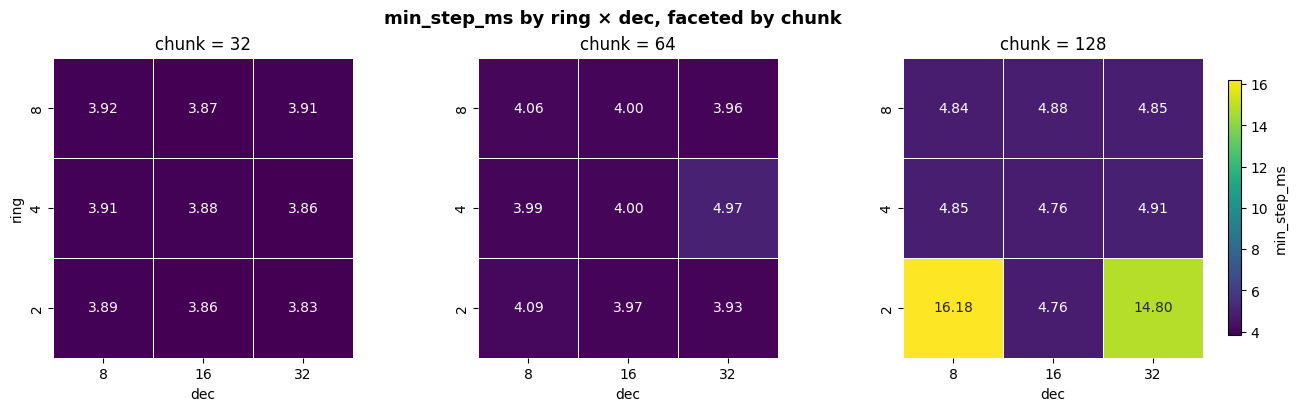

In [5]:
fig_min = plot_faceted_heatmap(df, value_col='min_step_ms')
plt.show()

## `mean_step_ms` heatmaps

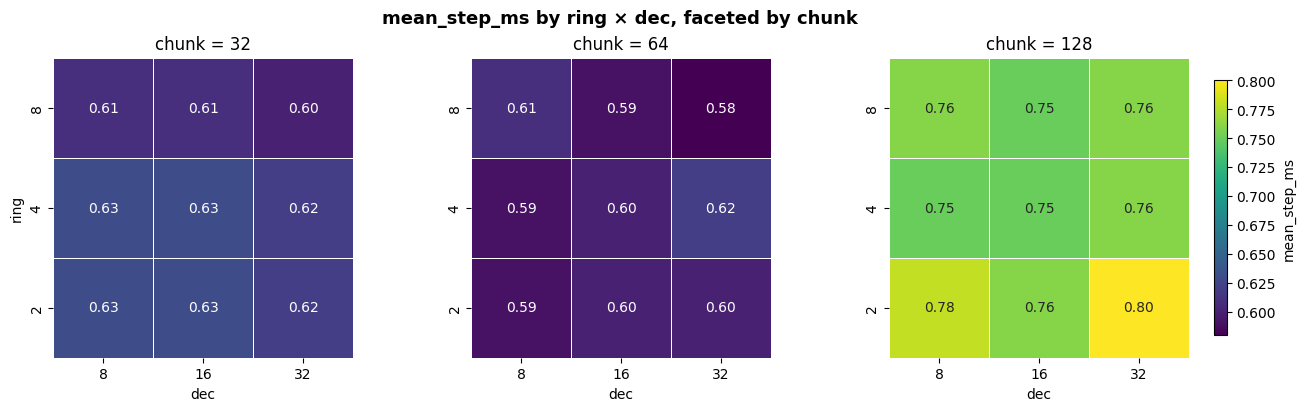

In [6]:
fig_mean = plot_faceted_heatmap(df, value_col='mean_step_ms')
plt.show()